Loaded studentInfo: 32,593 rows
Overall dropout rate: 31.2%

WELCH'S T-TESTS — numeric features vs dropout
  H0: Group means are equal (dropout vs no dropout)
  Significance threshold: p < 0.05

  Feature: Studied credits
    Mean (dropout)    : 91.430
    Mean (no dropout) : 74.476
    Difference        : +16.955
    t-statistic       : 32.086
    p-value           : 5.7032e-219
    Cohen's d         : 0.4206  (small effect)
    Levene's test     : variances unequal (Welch's is correct choice)  (p=0.0000)
    n (dropout)       : 10,156
    n (no dropout)    : 22,437
    ✅ SIGNIFICANT

  Feature: Previous attempts
    Mean (dropout)    : 0.187
    Mean (no dropout) : 0.153
    Difference        : +0.034
    t-statistic       : 5.715
    p-value           : 1.1132e-08
    Cohen's d         : 0.0711  (negligible effect)
    Levene's test     : variances unequal (Welch's is correct choice)  (p=0.0000)
    n (dropout)       : 10,156
    n (no dropout)    : 22,437
    ✅ SIGNIFICANT

  Featu

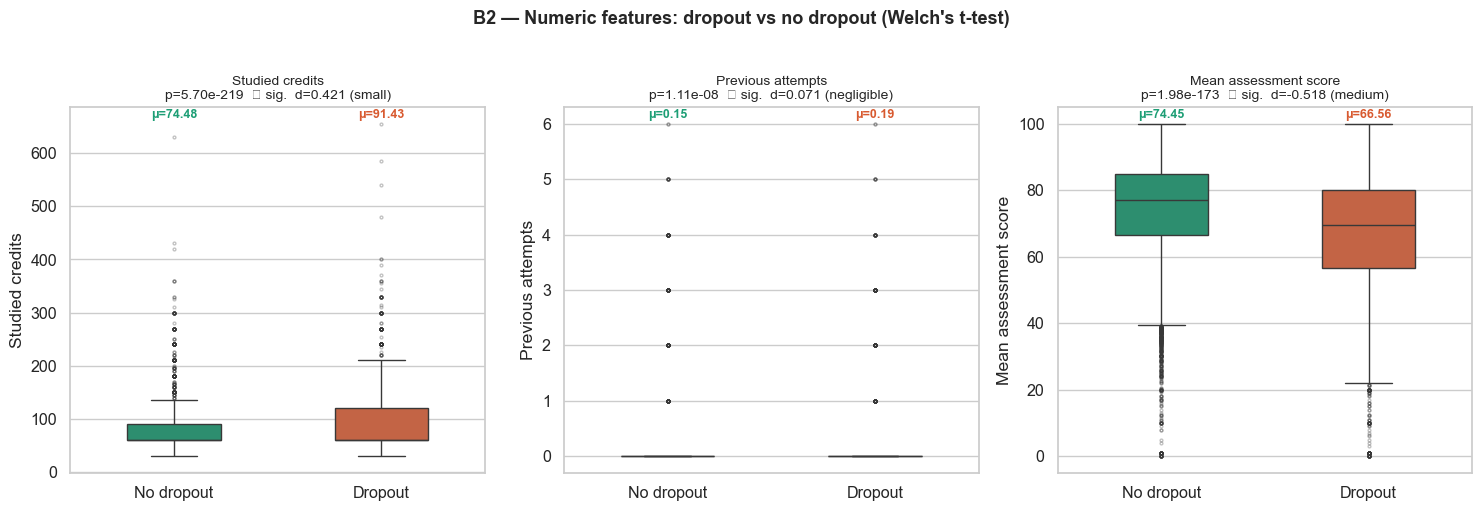

  Saved → ./outputs/phase3/block_b/B2_boxplots_ttest.png

B3: One-way ANOVA — studied_credits across age bands (dropout group only)...
  ANOVA: studied_credits ~ age_band  (dropout students only)
    F-statistic : 8.340
    p-value     : 2.4045e-04
    η²          : 0.0016  (negligible)
    Levene's p  : 0.0352  (unequal variance)
    ✅ SIGNIFICANT

  Mean studied_credits per age band (dropout students):
    0-35       mean=92.6  n=7,381
    35-55      mean=88.3  n=2,721
    55<=       mean=92.4  n=54



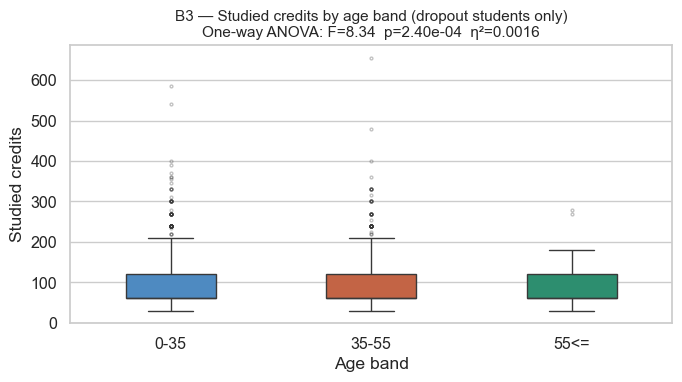

  Saved → ./outputs/phase3/block_b/B3_anova_credits_age.png

B4: Plotting violin plots for assessment score by dropout status...


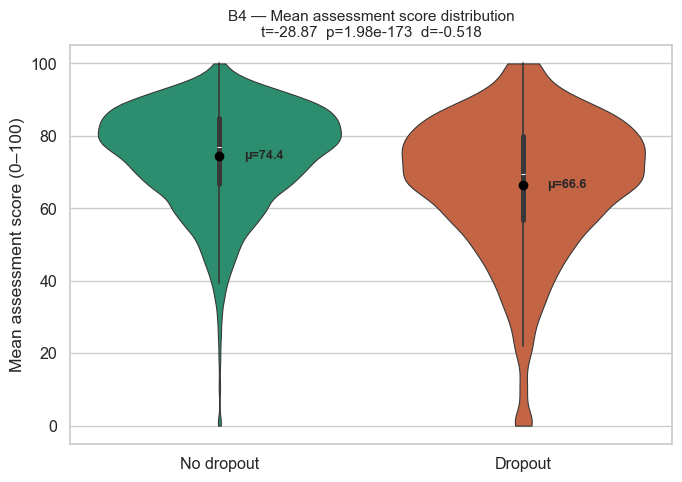

  Saved → ./outputs/phase3/block_b/B4_violin_score.png

B5: Plotting Cohen's d comparison chart...


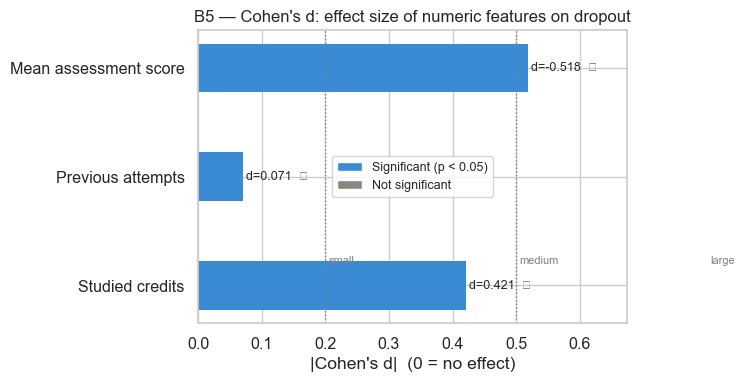

  Saved → ./outputs/phase3/block_b/B5_cohens_d_comparison.png

BLOCK B COMPLETE — T-Test and ANOVA Results

  Features tested (t-test)     : 3
  Significant (p < 0.05)       : 3  → ['Studied credits', 'Previous attempts', 'Mean assessment score']
  Not significant               : 0  → []

  Largest effect size           : Mean assessment score
                                  d = -0.5181  (medium)
                                  Dropout mean    = 66.56
                                  No-dropout mean = 74.45
                                  Difference      = -7.89

  ANOVA (studied_credits ~ age_band in dropout group):
    F = 8.340,  p = 2.4045e-04,  η² = 0.0016
    ✅ Significant

  Charts saved to: ./outputs/phase3/block_b/
    B2_boxplots_ttest.png
    B3_anova_credits_age.png
    B4_violin_score.png
    B5_cohens_d_comparison.png

─────────────────────────────────────────────────────────
Next → Run phase3_block_c_logistic_regression.py
─────────────────────────────────────────

In [1]:
"""
=============================================================
Phase 3 — Block B: T-Tests and ANOVA
=============================================================
Goal: Test whether numeric features differ significantly between
      dropout and non-dropout groups.

Tests used:
  ┌─────────────────────────────────────────────────────────┐
  │ Welch's t-test   │ 2 groups (dropout vs no dropout)     │
  │ One-way ANOVA    │ 3+ groups (e.g. age band × dropout)  │
  │ Levene's test    │ Check if group variances are equal    │
  │ Cohen's d        │ Effect size for t-tests               │
  │ Eta-squared (η²) │ Effect size for ANOVA                 │
  └─────────────────────────────────────────────────────────┘

Effect size interpretation (Cohen's d):
  |d| < 0.20  → negligible
  |d| = 0.20–0.50 → small
  |d| = 0.50–0.80 → medium
  |d| > 0.80  → large

Why Welch's t-test instead of Student's t-test?
  Welch's does NOT assume equal variances between groups —
  safer when group sizes are unequal (which ours are: ~30/70 split).
"""

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/phase3/block_b/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load data ─────────────────────────────────────────────────
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sa = pd.read_csv(DATA_PATH + 'studentAssessment.csv')
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

# Merge mean assessment score per student into studentInfo
mean_scores = (
    sa.groupby('id_student')['score']
      .mean()
      .reset_index()
      .rename(columns={'score': 'mean_score'})
)
si = si.merge(mean_scores, on='id_student', how='left')

print(f"Loaded studentInfo: {si.shape[0]:,} rows")
print(f"Overall dropout rate: {si['dropout'].mean()*100:.1f}%\n")


# =============================================================
# HELPERS
# =============================================================

def cohens_d(group1, group2):
    """
    Compute Cohen's d effect size for two independent groups.
    Formula: d = (mean1 - mean2) / pooled_std
    Pooled std uses the sample sizes as weights.
    """
    n1, n2     = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std if pooled_std > 0 else 0.0


def interpret_d(d):
    """Return a text label for Cohen's d effect size."""
    abs_d = abs(d)
    if abs_d < 0.20:   return 'negligible'
    elif abs_d < 0.50: return 'small'
    elif abs_d < 0.80: return 'medium'
    else:              return 'large'


def eta_squared(f_stat, dof_between, dof_within):
    """
    Compute eta-squared (η²) effect size for ANOVA.
    η² = SS_between / SS_total ≈ F×df_between / (F×df_between + df_within)
    """
    ss_between = f_stat * dof_between
    ss_total   = ss_between + dof_within
    return ss_between / ss_total if ss_total > 0 else 0.0


def run_ttest(df, numeric_col, target='dropout', label=None):
    """
    Run Welch's t-test comparing `numeric_col` between dropout=1 and dropout=0.
    Also runs Levene's test to check equal variance assumption.
    Returns a results dict.
    """
    label = label or numeric_col

    # Split into two groups, dropping NaNs
    clean    = df[[numeric_col, target]].dropna()
    group1   = clean[clean[target] == 1][numeric_col]   # dropout
    group0   = clean[clean[target] == 0][numeric_col]   # no dropout

    # Levene's test for equal variances
    # H0: variances are equal. If p < 0.05 → unequal variances confirmed.
    lev_stat, lev_p = stats.levene(group1, group0)

    # Welch's t-test (equal_var=False = Welch's; does NOT assume equal variances)
    t_stat, p_val = stats.ttest_ind(group1, group0, equal_var=False)

    # Cohen's d effect size
    d = cohens_d(group1, group0)

    return {
        'feature':      label,
        'mean_dropout': round(group1.mean(), 3),
        'mean_no_drop': round(group0.mean(), 3),
        'difference':   round(group1.mean() - group0.mean(), 3),
        't_stat':       round(t_stat, 3),
        'p_value':      p_val,
        'cohens_d':     round(d, 4),
        'effect_size':  interpret_d(d),
        'levene_p':     lev_p,
        'equal_var':    lev_p >= 0.05,
        'significant':  p_val < 0.05,
        'n_dropout':    len(group1),
        'n_no_drop':    len(group0),
    }


# =============================================================
# B1: Welch's t-tests for numeric features
# =============================================================
# We test three numeric features:
#   studied_credits     : workload per course
#   num_of_prev_attempts: how many retakes
#   mean_score          : average assessment score

numeric_features = [
    ('studied_credits',      'Studied credits'),
    ('num_of_prev_attempts', 'Previous attempts'),
    ('mean_score',           'Mean assessment score'),
]

print("=" * 60)
print("WELCH'S T-TESTS — numeric features vs dropout")
print("=" * 60)
print("  H0: Group means are equal (dropout vs no dropout)")
print("  Significance threshold: p < 0.05\n")

ttest_results = []

for col, label in numeric_features:
    r = run_ttest(si, col, label=label)
    ttest_results.append(r)

    sig  = "✅ SIGNIFICANT" if r['significant'] else "⚠  not significant"
    lev  = "equal" if r['equal_var'] else "unequal (Welch's is correct choice)"

    print(f"  Feature: {r['feature']}")
    print(f"    Mean (dropout)    : {r['mean_dropout']:.3f}")
    print(f"    Mean (no dropout) : {r['mean_no_drop']:.3f}")
    print(f"    Difference        : {r['difference']:+.3f}")
    print(f"    t-statistic       : {r['t_stat']:.3f}")
    print(f"    p-value           : {r['p_value']:.4e}")
    print(f"    Cohen's d         : {r['cohens_d']:.4f}  ({r['effect_size']} effect)")
    print(f"    Levene's test     : variances {lev}  (p={r['levene_p']:.4f})")
    print(f"    n (dropout)       : {r['n_dropout']:,}")
    print(f"    n (no dropout)    : {r['n_no_drop']:,}")
    print(f"    {sig}")
    print()

ttest_df = pd.DataFrame([{
    'Feature':       r['feature'],
    'Mean (dropout)':r['mean_dropout'],
    'Mean (no drop)':r['mean_no_drop'],
    'Difference':    r['difference'],
    't-stat':        r['t_stat'],
    'p-value':       r['p_value'],
    "Cohen's d":     r['cohens_d'],
    'Effect size':   r['effect_size'],
    'Significant':   '✅ Yes' if r['significant'] else '⚠ No',
} for r in ttest_results])

print("T-test summary table:")
print(ttest_df.to_string(index=False))
print()


# =============================================================
# B2: Box plots — numeric features by dropout status
# =============================================================
# Box plots show the FULL distribution of each numeric feature
# split by dropout status, letting us visually confirm the t-test.

print("B2: Plotting box plots for numeric features...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, numeric_features):
    clean = si[[col, 'dropout']].dropna()
    clean['Dropout'] = clean['dropout'].map({0: 'No dropout', 1: 'Dropout'})

    sns.boxplot(
        data=clean,
        x='Dropout',
        y=col,
        palette={'No dropout': COLORS['teal'], 'Dropout': COLORS['coral']},
        ax=ax,
        width=0.45,
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )

    # Annotate with group means
    for i, group_label in enumerate(['No dropout', 'Dropout']):
        mean_val = clean[clean['Dropout'] == group_label][col].mean()
        ax.text(i, ax.get_ylim()[1] * 0.97, f"μ={mean_val:.2f}",
                ha='center', fontsize=9, fontweight='bold',
                color=COLORS['teal'] if group_label == 'No dropout' else COLORS['coral'])

    # Fetch t-test result for annotation
    r = next(x for x in ttest_results if x['feature'] == label)
    p_str  = f"p={r['p_value']:.2e}" if r['p_value'] < 0.001 else f"p={r['p_value']:.4f}"
    d_str  = f"d={r['cohens_d']:.3f} ({r['effect_size']})"
    sig_str = "✅ sig." if r['significant'] else "⚠ n.s."

    ax.set_title(f"{label}\n{p_str}  {sig_str}  {d_str}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(label)

plt.suptitle("B2 — Numeric features: dropout vs no dropout (Welch's t-test)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B2_boxplots_ttest.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# B3: One-way ANOVA — studied_credits across age bands
# =============================================================
# ANOVA (Analysis of Variance) extends the t-test to 3+ groups.
# Here we test whether studied_credits differs across age bands,
# within the dropout group specifically.
#
# H0: Mean studied_credits is the same across all age bands.
# H1: At least one age band has a different mean.

print("B3: One-way ANOVA — studied_credits across age bands (dropout group only)...")

age_order = ['0-35', '35-55', '55<=']

# Filter to dropout students only for this ANOVA
dropout_only = si[si['dropout'] == 1].dropna(subset=['age_band', 'studied_credits'])

# Build one array per age group
groups_anova = [
    dropout_only[dropout_only['age_band'] == band]['studied_credits'].values
    for band in age_order
    if band in dropout_only['age_band'].values
]

# Levene's test for equal variance assumption
lev_stat_a, lev_p_a = stats.levene(*groups_anova)

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(*groups_anova)

# Effect size: eta-squared
dof_between = len(groups_anova) - 1
dof_within  = sum(len(g) for g in groups_anova) - len(groups_anova)
eta_sq      = eta_squared(f_stat, dof_between, dof_within)

print(f"  ANOVA: studied_credits ~ age_band  (dropout students only)")
print(f"    F-statistic : {f_stat:.3f}")
print(f"    p-value     : {p_anova:.4e}")
print(f"    η²          : {eta_sq:.4f}  ({'negligible' if eta_sq < 0.01 else 'small' if eta_sq < 0.06 else 'medium' if eta_sq < 0.14 else 'large'})")
print(f"    Levene's p  : {lev_p_a:.4f}  ({'equal variance' if lev_p_a >= 0.05 else 'unequal variance'})")
print(f"    {'✅ SIGNIFICANT' if p_anova < 0.05 else '⚠  not significant'}")
print()

# Group means for context
print("  Mean studied_credits per age band (dropout students):")
for band in age_order:
    group_data = dropout_only[dropout_only['age_band'] == band]['studied_credits']
    print(f"    {band:<10} mean={group_data.mean():.1f}  n={len(group_data):,}")
print()

# Plot ANOVA result
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(
    data=dropout_only,
    x='age_band',
    y='studied_credits',
    order=age_order,
    palette=[COLORS['blue'], COLORS['coral'], COLORS['teal']],
    ax=ax,
    width=0.45,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

p_str_anova = f"p={p_anova:.2e}" if p_anova < 0.001 else f"p={p_anova:.4f}"
ax.set_title(
    f"B3 — Studied credits by age band (dropout students only)\n"
    f"One-way ANOVA: F={f_stat:.2f}  {p_str_anova}  η²={eta_sq:.4f}",
    fontsize=11
)
ax.set_xlabel("Age band")
ax.set_ylabel("Studied credits")

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B3_anova_credits_age.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# B4: Violin plots — fuller picture of score distributions
# =============================================================
# Violin plots show the full shape of the distribution
# (not just median and IQR like box plots).
# Useful for seeing bimodal or skewed distributions.

print("B4: Plotting violin plots for assessment score by dropout status...")

clean_scores = si[['mean_score', 'dropout']].dropna()
clean_scores['Dropout status'] = clean_scores['dropout'].map(
    {0: 'No dropout', 1: 'Dropout'}
)

fig, ax = plt.subplots(figsize=(7, 5))

sns.violinplot(
    data=clean_scores,
    x='Dropout status',
    y='mean_score',
    palette={'No dropout': COLORS['teal'], 'Dropout': COLORS['coral']},
    ax=ax,
    inner='box',       # show mini box plot inside the violin
    cut=0,             # don't extend beyond the data range
    linewidth=0.8
)

# Add mean markers
for i, group in enumerate(['No dropout', 'Dropout']):
    mean_val = clean_scores[clean_scores['Dropout status'] == group]['mean_score'].mean()
    ax.plot(i, mean_val, 'o', color='black', markersize=6, zorder=5)
    ax.text(i + 0.08, mean_val, f"μ={mean_val:.1f}",
            va='center', fontsize=9, fontweight='bold')

score_r = next(x for x in ttest_results if 'score' in x['feature'].lower())
ax.set_title(
    f"B4 — Mean assessment score distribution\n"
    f"t={score_r['t_stat']:.2f}  p={score_r['p_value']:.2e}  d={score_r['cohens_d']:.3f}",
    fontsize=11
)
ax.set_ylabel("Mean assessment score (0–100)")
ax.set_xlabel("")

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B4_violin_score.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# B5: Cohen's d comparison chart
# =============================================================
# A clean chart comparing effect sizes across all t-tests.

print("B5: Plotting Cohen's d comparison chart...")

d_vals   = [r['cohens_d'] for r in ttest_results]
features = [r['feature']  for r in ttest_results]
sig_list = [r['significant'] for r in ttest_results]

bar_colors = [COLORS['blue'] if s else COLORS['gray'] for s in sig_list]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(features, [abs(d) for d in d_vals],
               color=bar_colors, edgecolor='none', height=0.45)

for bar, d, s in zip(bars, d_vals, sig_list):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"d={d:.3f}  {'✅' if s else '⚠'}",
            va='center', fontsize=9)

# Effect size threshold lines
for val, label in [(0.20, 'small'), (0.50, 'medium'), (0.80, 'large')]:
    ax.axvline(val, color='gray', linestyle=':', linewidth=1)
    ax.text(val + 0.005, 0.2, label, fontsize=8, color='gray')

ax.set_title("B5 — Cohen's d: effect size of numeric features on dropout",
             fontsize=12)
ax.set_xlabel("|Cohen's d|  (0 = no effect)")
ax.set_xlim(0, max(abs(d) for d in d_vals) * 1.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=COLORS['blue'], label='Significant (p < 0.05)'),
    Patch(facecolor=COLORS['gray'], label='Not significant'),
], fontsize=9)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B5_cohens_d_comparison.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# BLOCK B SUMMARY
# =============================================================
sig_ttest    = [r['feature'] for r in ttest_results if r['significant']]
nonsig_ttest = [r['feature'] for r in ttest_results if not r['significant']]
best_d       = max(ttest_results, key=lambda x: abs(x['cohens_d']))

print("=" * 60)
print("BLOCK B COMPLETE — T-Test and ANOVA Results")
print("=" * 60)
print(f"""
  Features tested (t-test)     : {len(ttest_results)}
  Significant (p < 0.05)       : {len(sig_ttest)}  → {sig_ttest}
  Not significant               : {len(nonsig_ttest)}  → {nonsig_ttest}

  Largest effect size           : {best_d['feature']}
                                  d = {best_d['cohens_d']:.4f}  ({best_d['effect_size']})
                                  Dropout mean    = {best_d['mean_dropout']:.2f}
                                  No-dropout mean = {best_d['mean_no_drop']:.2f}
                                  Difference      = {best_d['difference']:+.2f}

  ANOVA (studied_credits ~ age_band in dropout group):
    F = {f_stat:.3f},  p = {p_anova:.4e},  η² = {eta_sq:.4f}
    {'✅ Significant' if p_anova < 0.05 else '⚠ Not significant'}

  Charts saved to: {OUTPUT_PATH}
    B2_boxplots_ttest.png
    B3_anova_credits_age.png
    B4_violin_score.png
    B5_cohens_d_comparison.png

─────────────────────────────────────────────────────────
Next → Run phase3_block_c_logistic_regression.py
─────────────────────────────────────────────────────────
""")